🔌 Conectando ao Drive...
Mounted at /content/drive
📦 Extraindo dataset...
🔄 Carregando imagens...
Found 25331 files belonging to 8 classes.
Using 17732 files for training.
Found 25331 files belonging to 8 classes.
Using 7599 files for validation.

📥 Carregando modelo V4 completo...
✅ Modelo carregado com sucesso!

🚀 Continuando treinamento...
Epoch 1/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 224s 385ms/step - accuracy: 0.7012 - loss: 0.8177 - val_accuracy: 0.6743 - val_loss: 0.9148
Epoch 2/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 229s 412ms/step - accuracy: 0.6996 - loss: 0.8181 - val_accuracy: 0.6763 - val_loss: 0.9140
Epoch 3/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 241s 375ms/step - accuracy: 0.7018 - loss: 0.8183 - val_accuracy: 0.6751 - val_loss: 0.9149
Epoch 4/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 206s 371ms/step - accuracy: 0.7030 - loss: 0.8137 - val_accuracy: 0.6771 - val_loss: 0.9123
Epoch 5/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 263s 373ms/step - accuracy: 0.7003 - loss: 0.8138 - val_accuracy: 0.6788 - val_loss: 0.

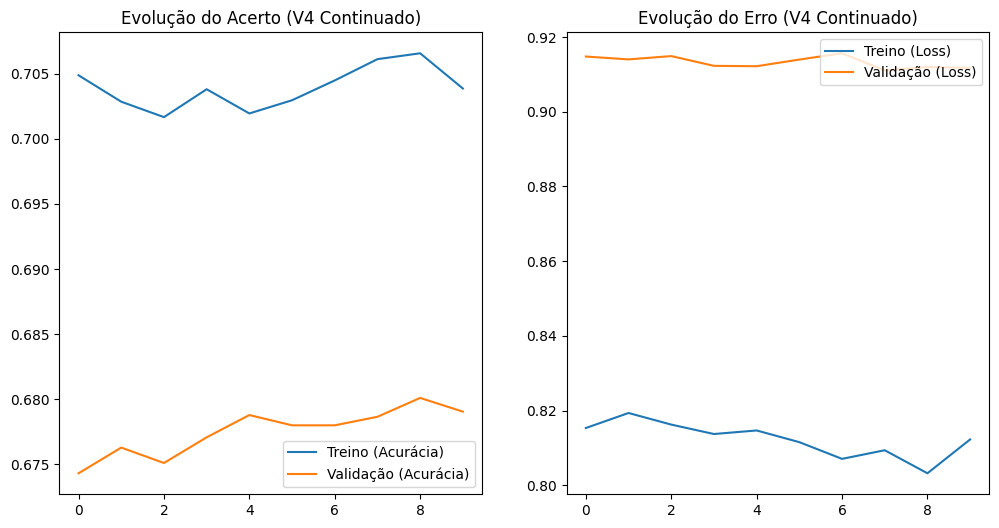

In [ ]:
import os
import zipfile
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import callbacks
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import drive

# 1. Conectar ao Drive
print("🔌 Conectando ao Drive...")
drive.mount('/content/drive')

caminho_zip = '/content/drive/MyDrive/PIBIC_Melanoma/dataset_PRONTO.zip'
pasta_dataset = '/content/dataset_final'
local_zip = '/content/dataset_pronto.zip'
caminho_modelo_v4 = '/content/drive/MyDrive/PIBIC_Melanoma/modelo_treinado_v4.keras'

# 2. Preparar Dataset
if not os.path.exists(pasta_dataset):
    print("📦 Extraindo dataset...")
    shutil.copy(caminho_zip, local_zip)
    with zipfile.ZipFile(local_zip, 'r') as z:
        z.extractall(pasta_dataset)

    for intruso in ['ISIC_2019_Training_Input', 'UNK']:
        p = os.path.join(pasta_dataset, intruso)
        if os.path.exists(p):
            shutil.rmtree(p)

    top = [d for d in os.listdir(pasta_dataset) if os.path.isdir(os.path.join(pasta_dataset, d))]
    if len(top) == 1:
        pasta_dataset = os.path.join(pasta_dataset, top[0])

img_size = (180, 180)
batch_size = 32

print("🔄 Carregando imagens...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# 3. Carregar modelo completo (com custom_objects)
print("\n📥 Carregando modelo V4 completo...")

model = tf.keras.models.load_model(
    caminho_modelo_v4,
    custom_objects={'preprocess_input': preprocess_input}
)

print("✅ Modelo carregado com sucesso!")

# 4. Recompilar com LR baixo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Continuar Treinamento
print("\n🚀 Continuando treinamento...")

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

# 6. Salvar nova versão
path_final = '/content/drive/MyDrive/PIBIC_Melanoma/modelo_v4_continuado.keras'
model.save(path_final)

print(f"✅ Novo modelo salvo em: {path_final}")

# 7. Gráficos
print("\n📊 Gerando gráficos...")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino (Acurácia)')
plt.plot(epochs_range, val_acc, label='Validação (Acurácia)')
plt.legend(loc='lower right')
plt.title('Evolução do Acerto (V4 Continuado)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino (Loss)')
plt.plot(epochs_range, val_loss, label='Validação (Loss)')
plt.legend(loc='upper right')
plt.title('Evolução do Erro (V4 Continuado)')

plt.show()

In [5]:
import os
import zipfile
import shutil
import tensorflow as tf
from google.colab import drive

# 1. Conecta ao Drive e define caminhos
drive.mount('/content/drive')
caminho_zip = '/content/drive/MyDrive/PIBIC_Melanoma/dataset_PRONTO.zip'
pasta_dataset = '/content/dataset_final'
local_zip = '/content/dataset_pronto.zip'

# 2. Garante que o dataset está extraído e limpo
if not os.path.exists(pasta_dataset):
    print("📦 Extraindo dataset...")
    shutil.copy(caminho_zip, local_zip)
    with zipfile.ZipFile(local_zip, 'r') as z: z.extractall(pasta_dataset)
    for intruso in ['ISIC_2019_Training_Input', 'UNK']:
        p = os.path.join(pasta_dataset, intruso)
        if os.path.exists(p): shutil.rmtree(p)
    top = [d for d in os.listdir(pasta_dataset) if os.path.isdir(os.path.join(pasta_dataset, d))]
    if len(top) == 1: pasta_dataset = os.path.join(pasta_dataset, top[0])

# 3. Cria a variável val_ds (O que estava faltando!)
val_ds = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset, validation_split=0.3, subset="validation", seed=123,
    image_size=(180, 180), batch_size=32
)

# 4. Reconstrói a arquitetura V4
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(180, 180, 3), include_top=False, weights='imagenet'
)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(180, 180, 3)),
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(8, activation='softmax')
])

# 5. LIGA O MODELO (O que faltava!)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Carrega os pesos e avalia
caminho_v4 = '/content/drive/MyDrive/PIBIC_Melanoma/modelo_v4_continuado.keras'
model.load_weights(caminho_v4)
print("✅ Pesos carregados e modelo compilado! Avaliando...")

loss, accuracy = model.evaluate(val_ds)
print(f"\n🎯 Resultado Final da V4: {accuracy * 100:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 25331 files belonging to 8 classes.
Using 7599 files for validation.


/tmp/ipython-input-623/3391800933.py:31: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


✅ Pesos carregados e modelo compilado! Avaliando...
238/238 ━━━━━━━━━━━━━━━━━━━━ 58s 220ms/step - accuracy: 0.6772 - loss: 0.9195

🎯 Resultado Final da V4: 67.86%
